R evolution equation correlations — Figure 4

This notebook does:

1. Load a DNS vorticity field `w(t,x,y)` from a NetCDF file (variable name: `w`).
2. Compute the correlations of the R evolution equation, both from a second order time derivative and the evolution equation discovered by SPIDER
3. Plot and save the data

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# User knobs
# ----------------------------
# Note: You want to create a dataset at higher resolution and lower viscosity. 
# This is an example for 2048^2 data at nu = 1e-6, remember at higher Re (lower nu) you may want to also add the term \nu\frac{\sigma^6}{2} \nabla_k\nabla_l \nabla^2 \bar u_i \nabla_k \nabla_l \nabla^2 \bar u_j
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/DNS.nc")

# Output: Where to save
OUT_DIR = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Make output directory
OUT_PATH = OUT_DIR / "AAA.txt"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Some imports that are needed
# ----------------------------
ds = xr.open_dataset(INP)
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")
    
nu = float(ds.attrs["nu"])  
w0 = jnp.asarray(ds["w"].values)
if w0.ndim != 3:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0.shape}")
Nt, Nx, Ny = w0.shape
w_hat_traj = jnp.fft.rfft2(w0, axes=(1,2))
print(f"Loaded w0 with shape (Nt, Nx, Ny) = {w0.shape}")
dt = float(ds.attrs["save_every"])  

Lengthscale = (2*jnp.pi/28)                 #Set you lengthscale here of you file
Delta_min = 0.01*Lengthscale                #Set minimum Delta you want
Delta_max = 1* Lengthscale                  #Set maximum Delta you want
Delta_amount = 20                           #How many Deltas in total to compute over

Loaded w0 with shape (Nt, Nx, Ny) = (10, 2048, 2048)


In [3]:
# ----------------------------
# Define the functions doing the work
# ----------------------------

def fourier_filter(field, Delta):
    Nx, Ny = field.shape[:2]
    q_pos = jnp.linspace(0, Nx//2, (Nx//2) + 1)
    q_neg = jnp.linspace(-((Nx//2) - 1), -1, ((Nx//2) - 1))
    q = jnp.concatenate((q_pos, q_neg))

    X = jnp.outer(q, jnp.ones_like(q))
    Y = jnp.outer(jnp.ones_like(q), q)
    R = jnp.sqrt(X**2 + Y**2)

    G = jnp.exp(-(R**2) * (Delta**2) / 24.0)

    filtered_field = jnp.zeros_like(field)

    if field.ndim == 4:  
        for i in range(field.shape[3]):
            for j in range(field.shape[2]):
                fourier_field = jnp.fft.fft2(field[:, :, j, i], s=(Nx, Ny))
                filtered_fourier_field = fourier_field * G
                filtered_field = filtered_field.at[:, :, j, i].set(
                    jnp.real(jnp.fft.ifft2(filtered_fourier_field, s=(Nx, Ny)))
                )

    elif field.ndim == 3:  
        for i in range(field.shape[2]):
            fourier_field = jnp.fft.fft2(field[:, :, i], s=(Nx, Ny))
            filtered_fourier_field = fourier_field * G
            filtered_field = filtered_field.at[:, :, i].set(
                jnp.real(jnp.fft.ifft2(filtered_fourier_field, s=(Nx, Ny)))
            )

    elif field.ndim == 2:  
        fourier_field = jnp.fft.fft2(field, s=(Nx, Ny))
        filtered_fourier_field = fourier_field * G
        filtered_field = jnp.real(jnp.fft.ifft2(filtered_fourier_field, s=(Nx, Ny)))

    else:
        raise ValueError("ERROR: field must have 2D, 3D, or 4D shape")

    return filtered_field


def compute_R(w_hat, Delta, w_to_v):
    Nx, Ny_half = w_hat.shape[0], w_hat.shape[1]
    Ny = (Ny_half - 1) * 2

    u_hat, v_hat = w_to_v(w_hat)
    u = jnp.fft.irfftn(u_hat, s=(Nx, Ny), axes=(0, 1))
    v = jnp.fft.irfftn(v_hat, s=(Nx, Ny), axes=(0, 1))
    u_bar = fourier_filter(u, Delta)
    v_bar = fourier_filter(v, Delta)

    u_pr = u - u_bar
    v_pr = v - v_bar
    bar_u_pr = fourier_filter(u_pr, Delta)
    bar_v_pr = fourier_filter(v_pr, Delta)

    Rxx = fourier_filter(u_pr**2, Delta) - bar_u_pr**2
    Ryy = fourier_filter(v_pr**2, Delta) - bar_v_pr**2
    Rxy = fourier_filter(u_pr * v_pr, Delta) - bar_u_pr * bar_v_pr
    
    trR = Rxx+Ryy
    R = jnp.stack([Rxx-0.5*trR, Ryy-0.5*trR, Rxy], axis=-1)

    R_hat = jnp.fft.rfftn(R, s=(Nx, Ny), axes=(0, 1))
    return R_hat, R


def compute_error_r_evo(w_hat: spectral.types.Array, Delta, w_to_v, nu):
    Nx, Ny_half = w_hat.shape[0], w_hat.shape[1]
    Ny = (Ny_half - 1) * 2

    dx = 2*np.pi / Nx
    dy = dx
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)[:, None]       # shape (Nx,1)
    ky = 2 * jnp.pi * jnp.fft.rfftfreq(Ny, d=dy)[None, :]      # shape (1,Ny/2+1)
    lap = -(kx**2 + ky**2)

    R_hat, R = compute_R(w_hat, Delta, w_to_v)
    u_hat, v_hat = w_to_v(w_hat)
    u = jnp.fft.irfftn(u_hat, s=(Nx, Ny), axes=(0, 1))
    v = jnp.fft.irfftn(v_hat, s=(Nx, Ny), axes=(0, 1))

    u_bar = fourier_filter(u, Delta)
    v_bar = fourier_filter(v, Delta)
    u_bar_hat = jnp.fft.rfftn(u_bar, s=(Nx, Ny), axes=(0, 1))
    v_bar_hat = jnp.fft.rfftn(v_bar, s=(Nx, Ny), axes=(0, 1))

    adv_R = (u_bar[..., None] * jnp.fft.irfftn(1j * kx[..., None] * R_hat, s=(Nx, Ny), axes=(0, 1))+ v_bar[..., None] * jnp.fft.irfftn(1j * ky[..., None] * R_hat, s=(Nx, Ny), axes=(0, 1)))


    dudx = jnp.fft.irfftn(1j * kx * u_bar_hat, s=(Nx, Ny), axes=(0, 1))    
    dudy = jnp.fft.irfftn(1j * ky * u_bar_hat, s=(Nx, Ny), axes=(0, 1))
    dvdx = jnp.fft.irfftn(1j * kx * v_bar_hat, s=(Nx, Ny), axes=(0, 1))
    dvdy = jnp.fft.irfftn(1j * ky * v_bar_hat, s=(Nx, Ny), axes=(0, 1))
    
    dudxlap = jnp.fft.irfftn(1j * kx * lap * u_bar_hat, s=(Nx, Ny), axes=(0, 1))
    dudylap = jnp.fft.irfftn(1j * ky * lap * u_bar_hat, s=(Nx, Ny), axes=(0, 1))
    dvdxlap = jnp.fft.irfftn(1j * kx * lap * v_bar_hat, s=(Nx, Ny), axes=(0, 1))
    dvdylap = jnp.fft.irfftn(1j * ky * lap * v_bar_hat, s=(Nx, Ny), axes=(0, 1))

    prod_R = jnp.stack([
        2 * R[..., 0] * dudx + 2 * R[..., 2] * dudy,
        2 * R[..., 2] * dvdx + 2 * R[..., 1] * dvdy,
        R[..., 1] * dudy + R[..., 0] * dvdx
    ], axis=-1)
    
    vis_R = nu* jnp.fft.irfftn(lap[...,None]*R_hat, s=(Nx, Ny), axes=(0, 1))
    
    S = jnp.stack([dudx,dvdy,0.5*(dudy+dvdx)], axis=-1)
    
    SR = S[...,0]*R[...,0]+S[...,1]*R[...,1]+2*S[...,2]*R[...,2]
    SR_term = jnp.stack([SR, SR, jnp.zeros_like(SR)], axis=-1)
    
    eps_term = (Delta**6/6912*(dudxlap**2+dudylap**2+dvdxlap**2+dvdylap**2))[...,None]*S
    
    I1 = jnp.sqrt(2 * dudx**2 + 2 * dvdy**2 + (dudy + dvdx)**2)
    w = jnp.fft.irfftn(w_hat, s=(Nx, Ny), axes=(0,1))
    I2 = jnp.sqrt(w**2)
    
    lin_R = 0.25 * (I1+I2)[..., None] * R
    
    return adv_R, prod_R, lin_R, vis_R, SR_term, eps_term


def get_R_deriv( w_minus1, w_plus1, dt):
    dRdt = (w_plus1 - w_minus1)/(2*dt)
    return dRdt

In [4]:
# ----------------------------
# Create the Data for Fig. 4
# ----------------------------

from tqdm import tqdm
from jax_cfd.spectral import utils as spectral_utils

Deltas = np.linspace(Delta_min,Delta_max,Delta_amount)
residuals = np.zeros((len(Deltas)))
grid = grids.Grid((Nx, Ny), domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi)))
w_to_v = spectral_utils.vorticity_to_velocity(grid)
T = Nt
for jj, Delta in enumerate(tqdm(Deltas, desc="Processing Deltas")):
    errs = []
    Nt = T - 2
    for kk in range(1, 1 + Nt):  
        w_hat_old  = w_hat_traj[kk - 1,:,:]
        w_hat_now  = w_hat_traj[kk,:,:]
        w_hat_next = w_hat_traj[kk + 1,:,:]

        _, R_old  = compute_R(w_hat_old,  Delta, w_to_v)
        _, R_next = compute_R(w_hat_next, Delta, w_to_v)

        dRdt = get_R_deriv(R_old, R_next, dt)

        adv_R, prod_R, lin_R, vis_R, SR_term, eps_term = compute_error_r_evo(w_hat_now, Delta, w_to_v, nu)

        res = -adv_R + prod_R +vis_R- SR_term + eps_term -lin_R
        
        dot = lambda A, B: jnp.real(jnp.vdot(A, B))   # flattens, conj(A)·B

        num = dot(res, dRdt)                                        # <A,B>
        den = jnp.maximum(dot(res, res), dot(dRdt, dRdt))           # max(<A,A>, <B,B>)
        #den = dot(dRdt, dRdt)
        err = num / (den + 1e-30)                                   # safe divide

        # if you're outside jit:
        errs.append(float(err))

    residuals[jj] = float(np.mean(errs))

Processing Deltas: 100%|██████████| 20/20 [00:11<00:00,  1.79it/s]


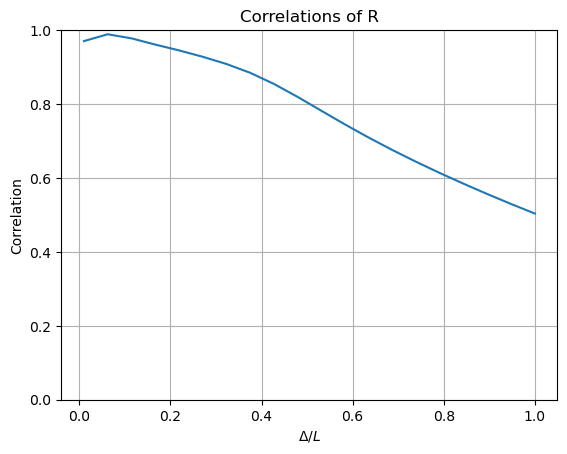

In [5]:
# ----------------------------
# Plot the data
# ----------------------------

import matplotlib.pyplot as plt

plt.plot(Deltas/Lengthscale, residuals)
plt.xlabel(r'$\Delta$/$L$')
plt.ylabel('Correlation')
plt.title('Correlations of R')
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [6]:
# ----------------------------
# Save it
# ----------------------------
x = np.asarray(Deltas/Lengthscale)
y = np.asarray(residuals)

with open(OUT_PATH, "w") as f:
    f.write("delta\n")
    for val in x:
        f.write(f"{val:.10e}\n")

    f.write("correlation\n")
    for val in y:
        f.write(f"{val:.10e}\n")

print(f"Saved to: {OUT_PATH}")

Saved to: /storage/home/hcoda1/4/mugliotti3/scratch/temporary/AAA.txt
